In [1]:
import numpy as np # linear algebra
import pandas as pd

df= pd.read_csv("datos/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [2]:
cat=df.select_dtypes(include=['str']).columns
num=df.select_dtypes(include=['int64','float64']).columns
print("==============Categoricas==========================")
print(cat)
print("===============Numericas=========================")
print(num)

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='str')
Index(['id', 'Age', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work'],
      dtype='str')


In [3]:
cat=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']
num=['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

In [4]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier, early_stopping, log_evaluation


In [15]:
X = df.drop(columns=['id', 'Will_Buy_EV'])
for c in cat:
    X[c] = X[c].astype('category')
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [16]:
print("Distribución completa:")
print(y.value_counts())

print("\nProporción:")
print(y.value_counts(normalize=True))
print("=========================")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

Distribución completa:
Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64

Proporción:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64
Train:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64

Validation:
Will_Buy_EV
0    0.825354
1    0.174646
Name: proportion, dtype: float64


In [17]:
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.725913318989971


In [18]:

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
   
    ("cat", categorical_transformer, cat),
])

In [19]:
model_lgb = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,           # equivalente aproximado a max_depth=6
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,        # sin esto, subsample se ignora
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=cat,
    callbacks=[early_stopping(100), log_evaluation(200)],
)

proba_lgb = model_lgb.predict_proba(X_val)[:, 1]
print("AUC LightGBM:", roc_auc_score(y_val, proba_lgb))

C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941426	valid_0's binary_logloss: 0.227235
[400]	valid_0's auc: 0.941567	valid_0's binary_logloss: 0.226961
Early stopping, best iteration is:
[375]	valid_0's auc: 0.94158	valid_0's binary_logloss: 0.226943
AUC LightGBM: 0.9415797518139668


In [21]:
umbrales = np.arange(0.10, 0.90, 0.01)
f1s = [f1_score(y_val, proba_lgb >= u) for u in umbrales]
umbral_lgb = umbrales[np.argmax(f1s)]
print(f"Mejor umbral: {umbral_lgb:.2f} | F1: {max(f1s):.4f}")

Mejor umbral: 0.36 | F1: 0.7161


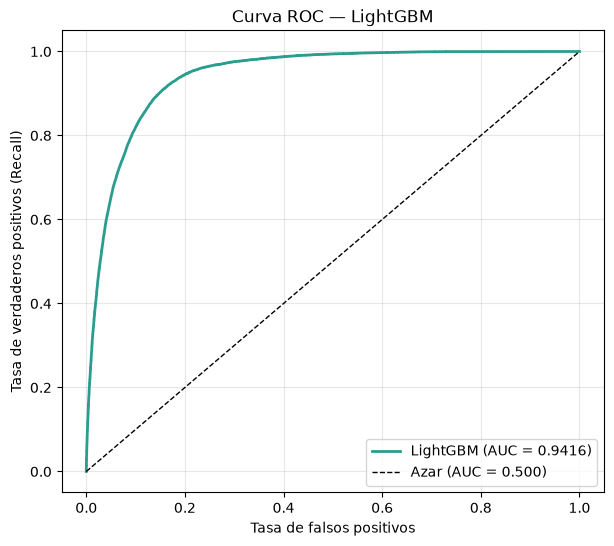

In [24]:

fpr, tpr, _ = roc_curve(y_val, proba_lgb)
auc_lgb = roc_auc_score(y_val, proba_lgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2a9d8f', lw=2, label=f"LightGBM (AUC = {auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Azar (AUC = 0.500)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Curva ROC — LightGBM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("imagenes/curva_roc_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

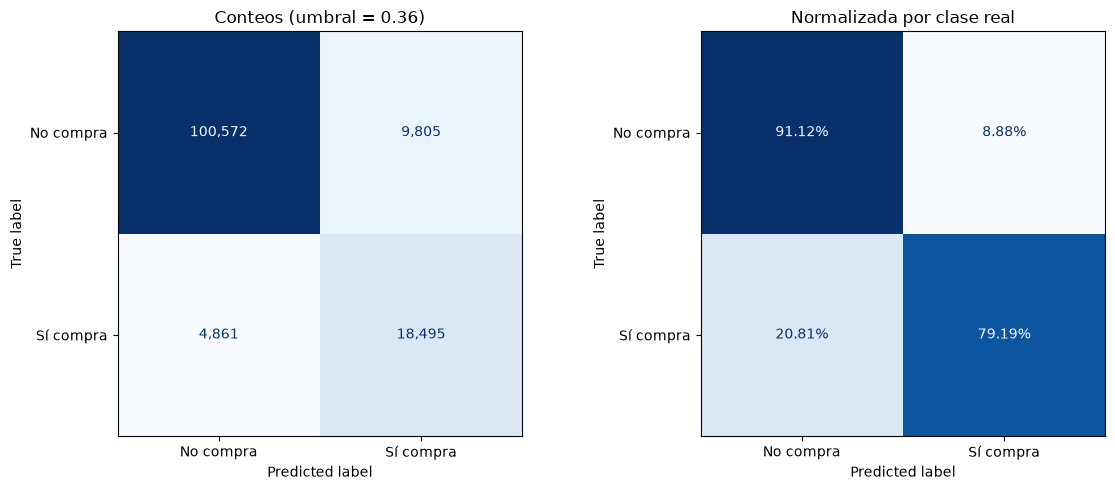

              precision    recall  f1-score   support

   No compra       0.95      0.91      0.93    110377
   Sí compra       0.65      0.79      0.72     23356

    accuracy                           0.89    133733
   macro avg       0.80      0.85      0.82    133733
weighted avg       0.90      0.89      0.89    133733



In [27]:

pred_lgb = (proba_lgb >= umbral_lgb).astype(int)
etiquetas = ["No compra", "Sí compra"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, pred_lgb), display_labels=etiquetas).plot(
    ax=ax[0], cmap="Blues", values_format=",d", colorbar=False)
ax[0].set_title(f"Conteos (umbral = {umbral_lgb:.2f})")

ConfusionMatrixDisplay(confusion_matrix(y_val, pred_lgb, normalize='true'), display_labels=etiquetas).plot(
    ax=ax[1], cmap="Blues", values_format=".2%", colorbar=False)
ax[1].set_title("Normalizada por clase real")

plt.tight_layout()
plt.savefig("imagenes/matriz_confusion_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_val, pred_lgb, target_names=etiquetas))

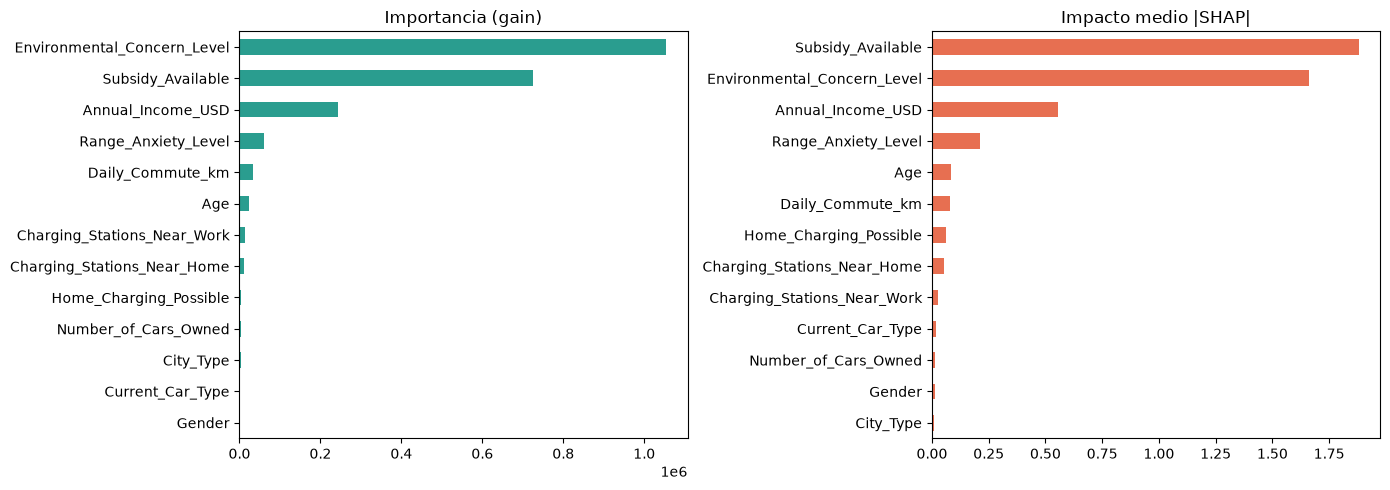

In [25]:
gain_lgb = pd.Series(
    model_lgb.booster_.feature_importance(importance_type='gain'),
    index=model_lgb.feature_name_
).sort_values()

muestra = X_val.sample(20000, random_state=42)
contrib_lgb = model_lgb.predict(muestra, pred_contrib=True)[:, :-1]
shap_lgb = pd.Series(np.abs(contrib_lgb).mean(axis=0), index=muestra.columns).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
gain_lgb.plot.barh(ax=ax[0], color='#2a9d8f', title='Importancia (gain)')
shap_lgb.plot.barh(ax=ax[1], color='#e76f51', title='Impacto medio |SHAP|')
plt.tight_layout()
plt.savefig("imagenes/importancia_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
import joblib, json, os

os.makedirs("modelo", exist_ok=True)

joblib.dump(model_lgb, "modelo/modelo_lgbm.pkl")

config_lgb = {
    "umbral": float(umbral_lgb),
    "auc_validacion": float(auc_lgb),
    "mejor_iteracion": int(model_lgb.best_iteration_),
    "categorias": {c: list(X_train[c].cat.categories) for c in cat},
    "columnas": list(X_train.columns),
}
with open("modelo/config_lgbm.json", "w", encoding="utf-8") as f:
    json.dump(config_lgb, f, indent=2, ensure_ascii=False)

print("Modelo guardado. Umbral:", config_lgb["umbral"])

Modelo guardado. Umbral: 0.3599999999999999


In [29]:
modelo_lgb = joblib.load("modelo/modelo_lgbm.pkl")
with open("modelo/config_lgbm.json", encoding="utf-8") as f:
    config_lgb = json.load(f)

df_test = pd.read_csv("datos/test.csv")
X_test = df_test[config_lgb["columnas"]].copy()
for c, cats in config_lgb["categorias"].items():
    X_test[c] = pd.Categorical(X_test[c], categories=cats)

proba_test_lgb = modelo_lgb.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "id": df_test["id"],
    "Will_Buy_EV": proba_test_lgb,
}).to_csv("predicciones/predicciones_lgbm.csv", index=False)